In [1]:
# CELL 0 - Global reproducibility controls (run first, before anything else)
import os
import random

SEED = 42

def set_global_seed(seed: int = SEED) -> None:
    """Seed every source of randomness we control. Call before importing/using
    TensorFlow's RNG-dependent ops (layer init, dropout, shuffling)."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    try:
        import numpy as np
        np.random.seed(seed)
    except ImportError:
        pass
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass

set_global_seed(SEED)
print(f"✅ Global seed set to {SEED}")


✅ Global seed set to 42


In [2]:
# CELL 1 - Install pinned dependencies
!pip install -q "mediapipe==0.10.21" "opencv-python==4.10.0.84" "tensorflow==2.18.0" \
                "kagglehub==0.3.4" "pandas==2.2.2" "numpy==1.26.4" \
                "scikit-learn==1.5.2" "tqdm==4.66.5" "matplotlib==3.9.2"


In [3]:
# CELL 2 - Imports
import os
import json

import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import matplotlib.pyplot as plt

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")


✅ Libraries imported successfully!
TensorFlow version: 2.18.0


In [4]:
# CELL 3 - Download the ASL Alphabet dataset from Kaggle
!pip install -q kagglehub
import kagglehub

print("🚀 Downloading ASL Alphabet dataset from Kaggle (~1.2GB)... this can take a few minutes.")

path = kagglehub.dataset_download("grassknoted/asl-alphabet")
print(f"✅ Dataset downloaded to: {path}")

print("📂 Contents of downloaded folder:")
print(os.listdir(path))


🚀 Downloading ASL Alphabet dataset from Kaggle (~1.2GB)... this can take a few minutes.


100%|██████████| 1.03G/1.03G [00:14<00:00, 75.8MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1
📂 Contents of downloaded folder:
['asl_alphabet_train', 'asl_alphabet_test']


In [5]:
# CELL 4 - Locate the training image folders and build the file list
# The Kaggle archive nests the actual class folders one level down, e.g.
# <path>/asl_alphabet_train/asl_alphabet_train/A/*.jpg -- find that folder
# instead of hardcoding the nesting depth, since it has changed across
# dataset versions.

def find_class_root(root, expected_classes=None):
    """Walk the extracted archive and return the first directory whose
    immediate subdirectories look like ASL Alphabet class folders
    (single uppercase letters, or 'space'/'del'/'nothing')."""
    expected_classes = expected_classes or (
        [chr(c) for c in range(ord("A"), ord("Z") + 1)] + ["space", "del", "nothing"]
    )
    expected_lower = {c.lower() for c in expected_classes}
    for dirpath, dirnames, _ in os.walk(root):
        names_lower = {d.lower() for d in dirnames}
        if len(names_lower & expected_lower) >= 20:  # most of the 29 classes present
            return dirpath
    return None

TRAIN_ROOT = find_class_root(path)
if TRAIN_ROOT is None:
    raise FileNotFoundError(
        "❌ Could not locate the ASL Alphabet class folders (A, B, C, ..., space, del, "
        "nothing) anywhere under the downloaded dataset path. The Kaggle archive layout "
        "may have changed -- inspect os.listdir(path) above and adjust find_class_root()."
    )

print(f"✅ Using class-folder root: {TRAIN_ROOT}")

CLASS_NAMES = sorted(
    d for d in os.listdir(TRAIN_ROOT) if os.path.isdir(os.path.join(TRAIN_ROOT, d))
)
print(f"📊 Found {len(CLASS_NAMES)} class folders: {CLASS_NAMES}")

assert len(CLASS_NAMES) == 29, (
    f"Expected 29 classes (A-Z + space + del + nothing), found {len(CLASS_NAMES)}. "
    "Check the dataset version / folder structure before continuing."
)

image_paths, labels = [], []
for cls in CLASS_NAMES:
    cls_dir = os.path.join(TRAIN_ROOT, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(cls_dir, fname))
            labels.append(cls)

print(f"✅ Found {len(image_paths)} total images across {len(CLASS_NAMES)} classes.")

class_counts = pd.Series(labels).value_counts()
print(f"📈 Images per class -- min: {class_counts.min()}, "
      f"max: {class_counts.max()}, mean: {class_counts.mean():.1f}")


✅ Using class-folder root: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train
📊 Found 29 class folders: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
✅ Found 87000 total images across 29 classes.
📈 Images per class -- min: 3000, max: 3000, mean: 3000.0


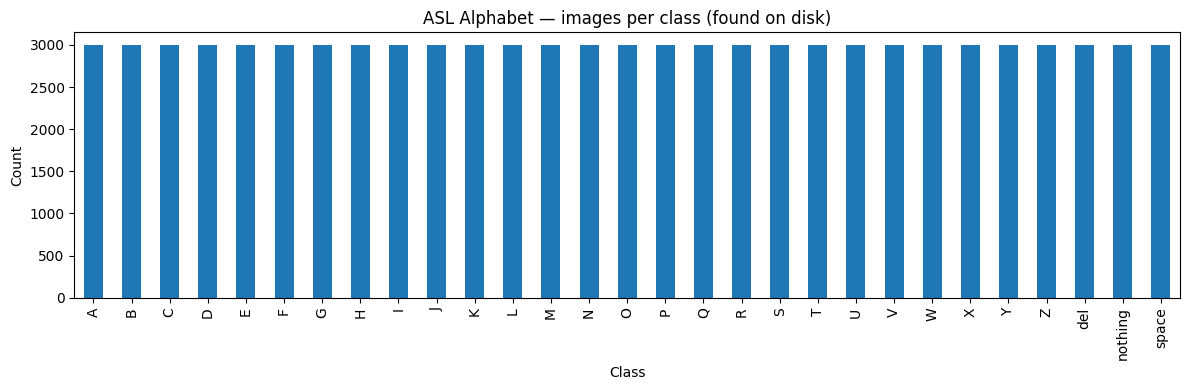

In [6]:
# CELL 5 - Sanity-check the label distribution before the expensive extraction step
plt.figure(figsize=(12, 4))
class_counts.sort_index().plot(kind="bar")
plt.title("ASL Alphabet — images per class (found on disk)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [7]:
# CELL 6 - Extract per-image hand landmarks using the modern MediaPipe Tasks API
#
# Unlike the WLASL video pipeline, there is no time axis here: each image
# yields a single 126-dim feature vector (21 landmarks * 3 coords * 2 hands).
# We drop the 2 presence-flag dims from the original FEATURE_DIM=128, since
# every ASL Alphabet image frames exactly one signing hand and a per-image
# classifier doesn't need to track which of two hands appeared across time.
#
# Extraction over ~87k images is the slow part of this notebook (expect
# 20-40+ minutes depending on runtime). Results are cached to .npy files so
# re-running the notebook (e.g. after a Colab disconnect) skips straight to
# CELL 7 instead of recomputing everything.

import urllib.request

import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

NUM_LANDMARK_DIMS = 126   # 2 hands * 21 points * 3 coords
FEATURE_DIM = NUM_LANDMARK_DIMS  # 126 -- no presence flags needed for single images

MODEL_PATH = "hand_landmarker.task"
if not os.path.exists(MODEL_PATH):
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/hand_landmarker/"
        "hand_landmarker/float16/1/hand_landmarker.task",
        MODEL_PATH,
    )

base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
landmarker_options = mp_vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=mp_vision.RunningMode.IMAGE,  # static images, not VIDEO mode
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
)


def normalize_hand_landmarks(flat_xyz63):
    """Center on the wrist (landmark 0) and scale by the hand's bounding-box
    diagonal, so a sign performed close to vs. far from the camera produces
    the same feature vector."""
    pts = np.array(flat_xyz63, dtype=np.float32).reshape(21, 3)
    wrist = pts[0].copy()
    pts -= wrist
    scale = np.linalg.norm(pts.max(axis=0) - pts.min(axis=0))
    if scale > 1e-6:
        pts /= scale
    return pts.flatten()


def extract_landmarks_from_image(image_path, landmarker):
    """Return a 126-dim feature vector for one image, or None if no hand
    was detected."""
    frame = cv2.imread(image_path)
    if frame is None or frame.size == 0:
        return None, "cannot_read_image"

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect(mp_image)

    if not result.hand_landmarks:
        return None, "no_hand_detected"

    landmarks = np.zeros(NUM_LANDMARK_DIMS, dtype=np.float32)
    for i, hand in enumerate(result.hand_landmarks[:2]):
        flat = []
        for lm in hand:
            flat.extend([lm.x, lm.y, lm.z])
        flat = normalize_hand_landmarks(flat)
        start = i * 63
        landmarks[start:start + 63] = flat

    return landmarks, None


FEATURES_CACHE = "asl_alphabet_features.npy"
LABELS_CACHE = "asl_alphabet_labels.npy"

if os.path.exists(FEATURES_CACHE) and os.path.exists(LABELS_CACHE):
    print("♻️  Found cached landmark features on disk -- loading instead of re-extracting.")
    X = np.load(FEATURES_CACHE)
    y = np.load(LABELS_CACHE, allow_pickle=True).tolist()
    extraction_failures = []
else:
    print("🔄 Extracting landmarks from images... this can take 20-40+ minutes for ~87k images.")

    X_list, y_list, extraction_failures = [], [], []
    with mp_vision.HandLandmarker.create_from_options(landmarker_options) as landmarker:
        for img_path, lbl in tqdm(list(zip(image_paths, labels)), total=len(image_paths)):
            feat, fail_reason = extract_landmarks_from_image(img_path, landmarker)
            if feat is not None:
                X_list.append(feat)
                y_list.append(lbl)
            else:
                extraction_failures.append({"image_path": img_path, "label": lbl, "reason": fail_reason})

    X = np.array(X_list, dtype=np.float32)
    y = y_list

    np.save(FEATURES_CACHE, X)
    np.save(LABELS_CACHE, np.array(y, dtype=object))
    print(f"💾 Cached features to {FEATURES_CACHE} / {LABELS_CACHE} for future re-runs.")

print(f"✅ Extracted {len(X)} valid feature vectors. Failed: {len(extraction_failures)}")
if extraction_failures:
    pd.DataFrame(extraction_failures).to_csv("landmark_extraction_failures.csv", index=False)
    print("   -> Logged to landmark_extraction_failures.csv for audit.")

per_class_success = pd.Series(y).value_counts().sort_index()
print("📈 Successfully extracted samples per class:")
print(per_class_success)


🔄 Extracting landmarks from images... this can take 20-40+ minutes for ~87k images.


100%|██████████| 87000/87000 [1:01:36<00:00, 23.54it/s]


💾 Cached features to asl_alphabet_features.npy / asl_alphabet_labels.npy for future re-runs.
✅ Extracted 63726 valid feature vectors. Failed: 23274
   -> Logged to landmark_extraction_failures.csv for audit.
📈 Successfully extracted samples per class:
A          2188
B          2205
C          1963
D          2457
E          2309
F          2873
G          2430
H          2373
I          2382
J          2576
K          2702
L          2521
M          1631
N          1293
O          2264
P          2041
Q          2127
R          2552
S          2560
T          2354
U          2513
V          2552
W          2456
X          2157
Y          2580
Z          2343
del        1780
nothing       1
space      1543
Name: count, dtype: int64


In [9]:
# Identify classes to keep (must have at least 3 samples for a 3-way stratified split)
MIN_SAMPLES = 3
class_counts_series = pd.Series(y).value_counts()
valid_classes = class_counts_series[class_counts_series >= MIN_SAMPLES].index.tolist()
removed_classes = class_counts_series[class_counts_series < MIN_SAMPLES].index.tolist()

if removed_classes:
    print(f"⚠️ Removing classes with too few samples: {removed_classes}")
    mask = np.isin(y, valid_classes)
    X = X[mask]
    y = [label for i, label in enumerate(y) if mask[i]]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)
print(f"✅ Final classes ({num_classes}): {list(le.classes_)}")

# 1. Split off a held-out test set (15%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_encoded, test_size=0.15, random_state=SEED, stratify=y_encoded
)

# 2. Split the remainder into train/val (resulting in ~70/15/15 split)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=SEED, stratify=y_train_full
)

print(f"📊 Split complete - Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Compute class weights to handle any remaining imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"✅ Class weights computed for {len(class_weight_dict)} classes.")

⚠️ Removing classes with too few samples: ['nothing']
✅ Final classes (28): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'space']
📊 Split complete - Train: 44632, Val: 9534, Test: 9559
✅ Class weights computed for 28 classes.


In [10]:
# CELL 8 - Build the model
#
# No temporal structure here (single image -> single feature vector), so we
# drop Conv1D/LSTM/attention pooling entirely in favor of a simple MLP.

def build_model(input_shape=(FEATURE_DIM,), num_classes=num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Dense(256, activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc"),
        ],
    )
    return model


model = build_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 126)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        32,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,556 (275.61 KB)

 Trainable params: 69,788 (272.61 KB)

 Non-trainable params: 768 (3.00 KB)

In [11]:
# CELL 9 - Train
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1)
checkpoint = ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1)
csv_logger = CSVLogger("training_log.csv")

safe_batch_size = max(1, min(128, len(X_train) // 4))
if safe_batch_size < 128:
    print(f"⚠️ Reducing batch_size to {safe_batch_size} given training set size {len(X_train)}.")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=safe_batch_size,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint, csv_logger],
    verbose=1,
)


Epoch 1/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6823 - loss: 1.1755 - top3_acc: 0.8451
Epoch 1: val_accuracy improved from None to 0.87120, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
349/349 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8364 - loss: 0.6143 - top3_acc: 0.9454 - val_accuracy: 0.8712 - val_loss: 0.9463 - val_top3_acc: 0.9874 - learning_rate: 0.0010
Epoch 2/50
346/349 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9378 - loss: 0.2399 - top3_acc: 0.9882
Epoch 2: val_accuracy improved from 0.87120 to 0.96707, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
349/349 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9434 - loss: 0.2214 - top3_acc: 0.9890 - val_accuracy: 0.9671 - val_loss: 0.1185 - val_top3_acc: 0.9938 - learning_rate: 0.0010
Epoch 3/50
346/349 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9524 - loss: 0.1815 - top3_acc: 0.9912
Epoch 3: val_accuracy improved from 0.96

In [12]:
# CELL 10 - Final test-set evaluation, save, and download
test_loss, test_acc, test_top3_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"🎯 Held-out Test Accuracy (top-1): {test_acc:.4f}")
print(f"🎯 Held-out Test Accuracy (top-3): {test_top3_acc:.4f}")

# Save in the native Keras v3 format (HDF5 is legacy as of Keras 3).
# Unlike the WLASL model, this MLP has no custom layers (no AttentionPooling1D),
# so there is no sawa_layers.py to ship alongside it -- predictor.py can call
# tf.keras.models.load_model("sawa_asl_model.keras") directly with no extra import.
model.save("sawa_asl_model.keras")
with open("sawa_label_classes.json", "w") as f:
    json.dump(le.classes_.tolist(), f)

print("✅ Model and labels saved.")
print("   -> Ship sawa_asl_model.keras + sawa_label_classes.json together.")
print("   -> No custom-layer module needed: this MLP only uses standard Keras layers.")

try:
    from google.colab import files
    files.download("sawa_asl_model.keras")
    files.download("sawa_label_classes.json")
    print("🎉 Download triggered via Colab.")
except ImportError:
    print(
        "ℹ️ Not running in Colab -- files were saved locally "
        "(sawa_asl_model.keras, sawa_label_classes.json). "
        "No browser download to trigger."
    )


🎯 Held-out Test Accuracy (top-1): 0.9905
🎯 Held-out Test Accuracy (top-3): 0.9979
✅ Model and labels saved.
   -> Ship sawa_asl_model.keras + sawa_label_classes.json together.
   -> No custom-layer module needed: this MLP only uses standard Keras layers.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 Download triggered via Colab.
